# MedGemma 1.5: Structured Chest X-Ray Report Generation### Journal Club 2026: Section 4, Multimodal LLMs

---## Section 1. Install DependenciesMedGemma 1.5 needs a recent `transformers`. `bitsandbytes` provides the 4-bitquantization that lets a 4B vision-language model fit in ~4 GB of VRAM.

In [2]:
!pip install --force-reinstall --no-cache-dir pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 298.4 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 12.3.0
    Uninstalling pillow-12.3.0:
      Successfully uninstalled pillow-12.3.0


In [1]:
RUN_INSTALLS = True

if RUN_INSTALLS:
    import subprocess
    import sys

    packages = [
        "kaggle",
        "transformers>=4.57.0",
        "accelerate",
        "bitsandbytes",
        "pillow",
        "pandas",
        "matplotlib",
        "rouge-score",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *packages])
    print("Dependencies installed. If transformers was upgraded, restart the runtime.")
else:
    print("Skipping installation. Set RUN_INSTALLS = True if imports fail.")

Dependencies installed. If transformers was upgraded, restart the runtime.


In [1]:
# Confirm a GPU is present. A 4-bit 4B VLM needs roughly 6 GB of VRAM with headroom.
import torch

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU: {name}  |  {total:.1f} GB")
else:
    print("No GPU detected. In Colab: Runtime > Change runtime type > T4 GPU.")
    print("CPU inference on a 4B VLM is possible but will take minutes per image.")


GPU: NVIDIA L4  |  22.0 GB


---
## Section 2. Kaggle Authentication

Same pattern as the Section 2 notebook. Upload either `kaggle.json` or a
`kaggle_API.txt` containing your API key.

Get a key from <https://www.kaggle.com/settings> → API → Create New Token.

In [5]:
from google.colab import files

uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))


import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("/content/kaggle.json"):
    shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("Kaggle token placed at /root/.kaggle/kaggle.json")
elif os.path.exists("/content/kaggle_API.txt"):
    shutil.copy("/content/kaggle_API.txt", "/root/.kaggle/access_token")
    os.chmod("/root/.kaggle/access_token", 0o600)
    print("Kaggle access token placed at /root/.kaggle/access_token")
else:
    raise FileNotFoundError("Upload kaggle.json or kaggle_API.txt first.")

Saving kaggle_API.txt to kaggle_API.txt
Uploaded files: ['kaggle_API.txt']
Kaggle access token placed at /root/.kaggle/access_token


---## Section 3. Download the Indiana University Chest X-Ray Dataset
Kaggle dataset identifier: `raddar/chest-xrays-indiana-university`

Dataset page: <https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university>

This is the Kaggle mirror of the **Open-i / IU X-ray** collection:
- **7,470** PNG chest X-ray images (frontal and lateral)
- **3,955** de-identified radiologist reports
- Two CSVs linking them by `uid`

Unlike the class-folder datasets used in Section 2, here every image carries a
**free-text report** — which is what makes report *generation* possible.

> **Expected download size:** ~13 GB.

In [6]:
!kaggle datasets list -s chest-xrays-indiana-university | head

ref                                    title                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------  ---------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
raddar/chest-xrays-indiana-university  Chest X-rays (Indiana University)  14134513955  2020-02-17 19:25:44.930000          29957        152  0.8235294        


In [7]:
!kaggle datasets download -d raddar/chest-xrays-indiana-university

Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 13.2G/13.2G [12:36<00:00, 18.7MB/s]



In [8]:
# unzip the dataset

from pathlib import Path
import zipfile

ZIP_PATH = Path("/content/chest-xrays-indiana-university.zip")
EXTRACT_DIR = Path("/content/iu_xray")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print(f"Extracted {ZIP_PATH.name} to {EXTRACT_DIR}")
print("\nTop-level contents:")
for p in sorted(EXTRACT_DIR.iterdir()):
    kind = "dir " if p.is_dir() else "file"
    print(f"  [{kind}] {p.name}")

Extracted chest-xrays-indiana-university.zip to /content/iu_xray

Top-level contents:
  [dir ] images
  [file] indiana_projections.csv
  [file] indiana_reports.csv


---
## Section 4. Build Image-Report Pairs

The dataset ships as two tables that must be joined:

| File | Contents |
|---|---|
| `indiana_reports.csv` | one row per **report**: `uid`, `indication`, `comparison`, `findings`, `impression`, MeSH terms |
| `indiana_projections.csv` | one row per **image**: `uid`, `filename`, `projection` (Frontal / Lateral) |

Joining on `uid` gives us `(image, report)` pairs. A single study can have several
images, so we keep the **frontal** view — the primary diagnostic projection, and
what most report-generation work conditions on.

The column resolver below matches names case-insensitively so the notebook survives
minor changes to the Kaggle mirror.

In [3]:
# helper functions to link the image-report
from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/iu_xray")


def find_file(root, name):
    matches = list(root.rglob(name))
    if not matches:
        raise FileNotFoundError(f"Could not find {name} under {root}")
    return matches[0]


def find_image_dir(root):
    # The PNGs live in a nested folder, commonly images/images_normalized.
    candidates = [p for p in root.rglob("*") if p.is_dir()
                  and any(c.suffix.lower() == ".png" for c in list(p.iterdir())[:50])]
    if not candidates:
        raise FileNotFoundError(f"No directory containing PNGs found under {root}")
    # Prefer the directory holding the most PNGs.
    return max(candidates, key=lambda d: len(list(d.glob("*.png"))))


reports_path = find_file(DATA_ROOT, "indiana_reports.csv")
projections_path = find_file(DATA_ROOT, "indiana_projections.csv")
IMAGE_DIR = find_image_dir(DATA_ROOT)

reports = pd.read_csv(reports_path)
projections = pd.read_csv(projections_path)

print(f"reports     : {reports_path}  ->  {reports.shape}")
print(f"projections : {projections_path}  ->  {projections.shape}")
print(f"images      : {IMAGE_DIR}  ->  {len(list(IMAGE_DIR.glob('*.png'))):,} PNGs")
print()
print("reports columns    :", list(reports.columns))
print("projections columns:", list(projections.columns))

reports     : /content/iu_xray/indiana_reports.csv  ->  (3851, 8)
projections : /content/iu_xray/indiana_projections.csv  ->  (7466, 3)
images      : /content/iu_xray/images/images_normalized  ->  7,470 PNGs

reports columns    : ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']
projections columns: ['uid', 'filename', 'projection']


In [4]:
def resolve(df, *candidates):
    """Case-insensitive column lookup, returns the first match."""
    lower = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    raise KeyError(f"None of {candidates} found in {list(df.columns)}")


R_UID = resolve(reports, "uid")
R_FINDINGS = resolve(reports, "findings")
R_IMPRESSION = resolve(reports, "impression")
R_INDICATION = resolve(reports, "indication")
R_COMPARISON = resolve(reports, "comparison")

P_UID = resolve(projections, "uid")
P_FILENAME = resolve(projections, "filename")
P_PROJECTION = resolve(projections, "projection")

pairs = projections.merge(reports, left_on=P_UID, right_on=R_UID, how="inner")

# Keep frontal views with a non-empty findings section.
frontal = pairs[pairs[P_PROJECTION].astype(str).str.lower().str.strip() == "frontal"].copy()
frontal = frontal[frontal[R_FINDINGS].notna()]
frontal = frontal[frontal[R_FINDINGS].astype(str).str.strip().str.len() > 20]

# Resolve each row to an absolute image path and drop rows whose file is missing.
frontal["image_path"] = frontal[P_FILENAME].apply(lambda f: str(IMAGE_DIR / str(f)))
frontal = frontal[frontal["image_path"].apply(lambda p: Path(p).exists())]

# One image per study.
frontal = frontal.drop_duplicates(subset=[P_UID]).reset_index(drop=True)

print(f"Usable frontal image-report pairs: {len(frontal):,}")
frontal[[P_UID, P_FILENAME, R_INDICATION, R_FINDINGS, R_IMPRESSION]].head()

Usable frontal image-report pairs: 3,199


,uid,filename,indication,findings,impression
0,1,1_IM-0001-4001.dcm.png,Positive TB test,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,2_IM-0652-1001.dcm.png,Preop bariatric surgery.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,4,4_IM-2050-1001.dcm.png,XXXX-year-old XXXX with XXXX.,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
3,5,5_IM-2117-1003002.dcm.png,Chest and nasal congestion.,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.
4,6,6_IM-2192-1001.dcm.png,Evaluate for infection,Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.


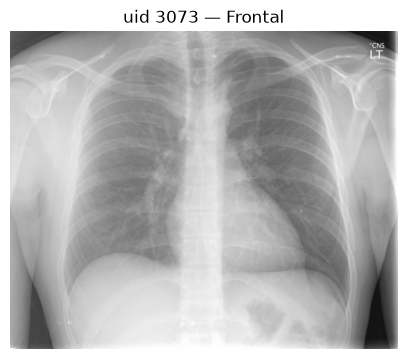

INDICATION : XXXX-year-old male with XXXX and rib pain.
COMPARISON : None.

FINDINGS   : Heart size and cardiomediastinal contours are normal. Lungs are clear without focal airspace opacity, pleural effusion, or pneumothorax. No displaced rib fracture.

IMPRESSION : Negative for acute cardiopulmonary findings.


In [5]:
# Inspect one complete pair: what the model sees, and what the radiologist wrote.
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
demo = frontal.sample(n=1, random_state=SEED).iloc[0]

img = Image.open(demo["image_path"]).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"uid {demo[P_UID]} — {demo[P_PROJECTION]}")
plt.show()

print("INDICATION :", demo[R_INDICATION])
print("COMPARISON :", demo[R_COMPARISON])
print()
print("FINDINGS   :", demo[R_FINDINGS])
print()
print("IMPRESSION :", demo[R_IMPRESSION])

### A note on the text you just printedNotice the `XXXX` tokens. The IU reports were **de-identified by redaction**, and theredaction removed more than names — dates, ages, and sometimes anatomical qualifiersare gone too.This matters for the session's theme: the "ground truth" we will evaluate against isitself degraded text. When a generated report and a reference report disagree, thereference is not automatically right.

---
## Section 5. Load MedGemma 1.5 4B

`unsloth/medgemma-1.5-4b-it` is an instruction-tuned medical vision-language model.
Architecturally it follows the pipeline from the Section 4 introduction:

**image → image encoder → visual tokens → multimodal connector → LM decoder → text**

We load it with **4-bit NF4 quantization** so the weights occupy roughly 4 GB instead
of ~9 GB in bfloat16. Computation still happens in bfloat16; only storage is
quantized. Set `LOAD_IN_4BIT = False` if you have an L4 or A100 and want full quality.

In [6]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

MODEL_ID = "unsloth/medgemma-1.5-4b-it"
LOAD_IN_4BIT = True

if LOAD_IN_4BIT:
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    model_kwargs = {"quantization_config": quant_config}
else:
    quant_config = None
    model_kwargs = {"torch_dtype": torch.bfloat16}

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    device_map="auto",
    **model_kwargs,
)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded {MODEL_ID}")
print(f"Parameters: {n_params/1e9:.2f} B")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.59k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

Loaded unsloth/medgemma-1.5-4b-it
Parameters: 2.49 B
GPU memory allocated: 3.01 GB


---
## Section 6. Design the Structured Prompt

This is the heart of the notebook.

An instruction-tuned VLM asked *"describe this X-ray"* will produce fluent but
unconstrained prose — variable in length, section order, and hedging. That output is
hard to evaluate and harder to audit. **A structured prompt turns free generation into
a form-filling task**, which is what makes the output comparable to a real report.

Our prompt has three parts:

| Part | Role |
|---|---|
| **System message** | Fixes the persona and the non-negotiable rules (report only what is visible, no speculation) |
| **Schema** | Names the exact sections and their order, so every output is parseable |
| **Clinical context** | Injects the real `INDICATION` from the report, mirroring how a radiologist reads with a question in mind |

Note that the third part is exactly the tension raised in Slide 2 of the introduction:
context can sharpen interpretation, or it can bias the model toward confirming the
indication it was handed. Section 9 lets you test which is happening.

In [7]:
SYSTEM_PROMPT = (
    "You are an experienced board-certified radiologist reporting a chest radiograph. "
    "Report only findings that are visible in the provided image. "
    "Do not infer patient history, prior studies, or laboratory results. "
    "If a structure is not assessable on this projection, state that explicitly "
    "rather than assuming it is normal. "
    "Use standard radiological terminology and keep each section concise."
)

REPORT_SCHEMA = (
    "Produce a structured radiology report using exactly these sections, "
    "each on its own line, in this order:\n"
    "\n"
    "TECHNIQUE: modality and projection.\n"
    "FINDINGS: systematic description covering, in order — lungs and pleura, "
    "cardiomediastinal silhouette, bones and soft tissues, and any devices or lines.\n"
    "IMPRESSION: a numbered list of the clinically significant conclusions, "
    "most important first. If the study is normal, state that in one line.\n"
    "\n"
    "Do not add any sections beyond these three. "
    "Do not include preamble, commentary, or disclaimers."
)


def build_messages(image, indication=None, schema=REPORT_SCHEMA, system=SYSTEM_PROMPT):
    """Assemble a MedGemma chat payload from an image and optional clinical context."""
    parts = []
    if indication and str(indication).strip() and str(indication).strip().lower() != "nan":
        parts.append(f"CLINICAL INDICATION: {str(indication).strip()}")
    parts.append(schema)
    user_text = "\n\n".join(parts)

    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": system}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": user_text},
            ],
        },
    ]


# Preview the exact text the model will receive for our demo case.
preview = build_messages(img, demo[R_INDICATION])
print(preview[0]["content"][0]["text"])
print("\n" + "=" * 70 + "\n")
print(preview[1]["content"][1]["text"])

You are an experienced board-certified radiologist reporting a chest radiograph. Report only findings that are visible in the provided image. Do not infer patient history, prior studies, or laboratory results. If a structure is not assessable on this projection, state that explicitly rather than assuming it is normal. Use standard radiological terminology and keep each section concise.


CLINICAL INDICATION: XXXX-year-old male with XXXX and rib pain.

Produce a structured radiology report using exactly these sections, each on its own line, in this order:

TECHNIQUE: modality and projection.
FINDINGS: systematic description covering, in order — lungs and pleura, cardiomediastinal silhouette, bones and soft tissues, and any devices or lines.
IMPRESSION: a numbered list of the clinically significant conclusions, most important first. If the study is normal, state that in one line.

Do not add any sections beyond these three. Do not include preamble, commentary, or disclaimers.


---
## Section 7. Generate a Report

`processor.apply_chat_template` converts the message list into token IDs plus a
preprocessed image tensor. The image becomes a block of **visual tokens** inserted
into the sequence — the language model attends to them exactly as it attends to text.

We decode greedily (`do_sample=False`) so the demo is reproducible. Sampling produces
more natural prose but different output on every run, which is the wrong property for
a clinical report and for a live demo.

In [8]:
import time


@torch.inference_mode()
def generate_report(image, indication=None, max_new_tokens=512, do_sample=False,
                    temperature=1.0, schema=REPORT_SCHEMA, system=SYSTEM_PROMPT):
    """Run MedGemma on one image and return the decoded report text."""
    messages = build_messages(image, indication, schema=schema, system=system)

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    prompt_len = inputs["input_ids"].shape[-1]

    gen_kwargs = {"max_new_tokens": max_new_tokens, "do_sample": do_sample}
    if do_sample:
        gen_kwargs["temperature"] = temperature
        gen_kwargs["top_p"] = 0.95

    output = model.generate(**inputs, **gen_kwargs)
    new_tokens = output[0][prompt_len:]
    return processor.decode(new_tokens, skip_special_tokens=True).strip()


t0 = time.time()
generated = generate_report(img, demo[R_INDICATION])
print(f"Generated in {time.time() - t0:.1f}s\n")
print(generated)

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Generated in 8.5s

FINDINGS: The lungs are clear. There is no pleural effusion or pneumothorax. The cardiomediastinal silhouette is normal. The heart size is normal. The mediastinum is normal. The visualized bones are unremarkable. No devices or lines are seen. IMPRESSION: No acute cardiopulmonary process.


In [10]:
# Parse the structured output back into fields.
# If this succeeds cleanly, the schema constraint did its job.
import re


def parse_report(text):
    """Split a generated report into its schema sections."""
    sections = {"TECHNIQUE": "", "FINDINGS": "", "IMPRESSION": ""}
    # Tolerate markdown decoration, e.g. "**FINDINGS:**" or "## Findings :".
    pattern = r"[#*\s]*(TECHNIQUE|FINDINGS|IMPRESSION)[*\s]*:[*\s]*"
    tokens = re.split(pattern, text, flags=re.IGNORECASE)

    current = None
    for tok in tokens:
        key = tok.strip().upper()
        if key in sections:
            current = key
        elif current is not None:
            sections[current] = tok.strip().strip("*").strip()
    return sections


parsed = parse_report(generated)
for section, body in parsed.items():
    status = "ok" if body else "MISSING"
    print(f"--- {section} [{status}] ---")
    print(body if body else "(not produced)")
    print()

--- TECHNIQUE [MISSING] ---
(not produced)

--- FINDINGS [ok] ---
The lungs are clear. There is no pleural effusion or pneumothorax. The cardiomediastinal silhouette is normal. The heart size is normal. The mediastinum is normal. The visualized bones are unremarkable. No devices or lines are seen.

--- IMPRESSION [ok] ---
No acute cardiopulmonary process.



---
## Section 8. Compare Against the Radiologist Report

Now the real question: how close is the generated report to what the radiologist wrote?

We use two complementary views:

1. **ROUGE-L** — longest-common-subsequence overlap. This is the standard metric in
   the report-generation literature, and it measures *wording* similarity.
2. **Finding-level agreement** — we check a list of common radiological findings and
   ask whether each is asserted, negated, or absent in each report. This is a crude
   stand-in for the clinical-efficacy metrics (CheXbert F1, RadGraph) used in MAIRA-2.

Watch for cases where these two disagree. A report can score well on ROUGE while
missing the one finding that matters, or score badly while being clinically correct
in different words. **That gap is the point of this section.**

In [11]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)


def reference_report(row):
    """Concatenate the radiologist findings and impression as the reference text."""
    findings = str(row[R_FINDINGS]).strip() if pd.notna(row[R_FINDINGS]) else ""
    impression = str(row[R_IMPRESSION]).strip() if pd.notna(row[R_IMPRESSION]) else ""
    return f"FINDINGS: {findings}\n\nIMPRESSION: {impression}".strip()


def generated_body(parsed_sections):
    """Drop TECHNIQUE, which has no counterpart in the IU reference text."""
    return (f"FINDINGS: {parsed_sections['FINDINGS']}\n\n"
            f"IMPRESSION: {parsed_sections['IMPRESSION']}").strip()


ref_text = reference_report(demo)
gen_text = generated_body(parsed)

print("=" * 34, "GENERATED", "=" * 34)
print(gen_text)
print()
print("=" * 33, "RADIOLOGIST", "=" * 33)
print(ref_text)
print()

scores = scorer.score(ref_text, gen_text)
print("=" * 30, "LEXICAL OVERLAP", "=" * 30)
for metric, score in scores.items():
    print(f"{metric:>8}  P={score.precision:.3f}  R={score.recall:.3f}  F1={score.fmeasure:.3f}")

================================== GENERATED ==================================
FINDINGS: The lungs are clear. There is no pleural effusion or pneumothorax. The cardiomediastinal silhouette is normal. The heart size is normal. The mediastinum is normal. The visualized bones are unremarkable. No devices or lines are seen.

IMPRESSION: No acute cardiopulmonary process.

================================= RADIOLOGIST =================================
FINDINGS: Heart size and cardiomediastinal contours are normal. Lungs are clear without focal airspace opacity, pleural effusion, or pneumothorax. No displaced rib fracture.

IMPRESSION: Negative for acute cardiopulmonary findings.

============================== LEXICAL OVERLAP ==============================
  rouge1  P=0.405  R=0.586  F1=0.479
  rouge2  P=0.171  R=0.250  F1=0.203
  rougeL  P=0.286  R=0.414  F1=0.338


In [12]:
# Finding-level agreement: a keyword proxy for clinical-efficacy metrics.
FINDING_TERMS = {
    "cardiomegaly":       ["cardiomegaly", "enlarged heart", "enlarged cardiac", "cardiac enlargement"],
    "pleural effusion":   ["pleural effusion", "effusion"],
    "consolidation":      ["consolidation", "airspace opacity", "airspace disease"],
    "pneumothorax":       ["pneumothorax"],
    "edema":              ["pulmonary edema", "edema", "vascular congestion"],
    "atelectasis":        ["atelectasis", "atelectatic"],
    "nodule / mass":      ["nodule", "mass", "lesion"],
    "fracture":           ["fracture"],
    "device / line":      ["catheter", "picc", "tube", "pacemaker", "sternotomy", "wires"],
    "degenerative spine": ["degenerative", "spondylosis", "osteophyte"],
}

NEGATION_CUES = ["no ", "without", "absence of", "negative for", "free of",
                 "not seen", "unremarkable", "clear of", "resolved", "rule out"]


def assert_status(text, terms, window=45):
    """Return 'present', 'absent', or 'not mentioned' for a finding.

    Crude rule: if a negation cue appears shortly before the term, treat as negated.
    This is deliberately simple so its failure modes stay visible.
    """
    low = " " + text.lower().replace("\n", " ") + " "
    found = False
    for term in terms:
        for m in re.finditer(re.escape(term), low):
            found = True
            prefix = low[max(0, m.start() - window):m.start()]
            if any(cue in prefix for cue in NEGATION_CUES):
                return "absent"
    return "present" if found else "not mentioned"


rows = []
for finding, terms in FINDING_TERMS.items():
    rows.append({
        "finding": finding,
        "generated": assert_status(gen_text, terms),
        "radiologist": assert_status(ref_text, terms),
    })

agreement = pd.DataFrame(rows)
agreement["match"] = agreement["generated"] == agreement["radiologist"]

print("Finding-level comparison for this case:\n")
print(agreement.to_string(index=False))
print()
mentioned = agreement[(agreement["generated"] != "not mentioned") |
                      (agreement["radiologist"] != "not mentioned")]
if len(mentioned):
    print(f"Agreement on findings mentioned by either report: "
          f"{mentioned['match'].sum()}/{len(mentioned)}")

Finding-level comparison for this case:

           finding     generated   radiologist  match
      cardiomegaly not mentioned not mentioned   True
  pleural effusion        absent        absent   True
     consolidation not mentioned        absent  False
      pneumothorax        absent       present  False
             edema not mentioned not mentioned   True
       atelectasis not mentioned not mentioned   True
     nodule / mass not mentioned not mentioned   True
          fracture not mentioned        absent  False
     device / line not mentioned not mentioned   True
degenerative spine not mentioned not mentioned   True

Agreement on findings mentioned by either report: 1/4


---
## Section 9. Batch Evaluation

One case proves nothing. Here we run the same pipeline over `N_CASES` studies and
aggregate.

Start with `N_CASES = 8` — on a T4 in 4-bit, expect roughly 20–40 seconds per case.
Raise it if you have time or a faster GPU.

In [13]:
N_CASES = 8

batch = frontal.sample(n=N_CASES, random_state=SEED).reset_index(drop=True)
results = []

for i, row in batch.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")
    t0 = time.time()
    raw = generate_report(image, row[R_INDICATION])
    elapsed = time.time() - t0

    sections = parse_report(raw)
    gen = generated_body(sections)
    ref = reference_report(row)
    s = scorer.score(ref, gen)

    results.append({
        "uid": row[P_UID],
        "image_path": row["image_path"],
        "indication": row[R_INDICATION],
        "generated_raw": raw,
        "generated": gen,
        "reference": ref,
        "rouge1_f1": s["rouge1"].fmeasure,
        "rouge2_f1": s["rouge2"].fmeasure,
        "rougeL_f1": s["rougeL"].fmeasure,
        "parsed_ok": all(sections[k] for k in ("FINDINGS", "IMPRESSION")),
        "seconds": elapsed,
    })
    print(f"[{i+1}/{N_CASES}] uid={row[P_UID]}  "
          f"ROUGE-L={s['rougeL'].fmeasure:.3f}  {elapsed:.1f}s")

results_df = pd.DataFrame(results)
print()
print("Schema compliance: "
      f"{results_df['parsed_ok'].sum()}/{len(results_df)} reports parsed cleanly")
print()
print(results_df[["rouge1_f1", "rouge2_f1", "rougeL_f1", "seconds"]].describe().round(3))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[1/8] uid=3073  ROUGE-L=0.338  7.0s
[2/8] uid=1125  ROUGE-L=0.133  9.0s
[3/8] uid=728  ROUGE-L=0.155  10.0s
[4/8] uid=3095  ROUGE-L=0.183  13.5s
[5/8] uid=3110  ROUGE-L=0.220  15.0s
[6/8] uid=3382  ROUGE-L=0.319  12.8s
[7/8] uid=1223  ROUGE-L=0.348  11.4s
[8/8] uid=1079  ROUGE-L=0.281  9.9s

Schema compliance: 6/8 reports parsed cleanly

       rouge1_f1  rouge2_f1  rougeL_f1  seconds
count      8.000      8.000      8.000    8.000
mean       0.376      0.127      0.247   11.086
std        0.108      0.074      0.085    2.604
min        0.152      0.019      0.133    7.035
25%        0.343      0.093      0.176    9.654
50%        0.382      0.124      0.251   10.720
75%        0.454      0.177      0.324   12.985
max        0.487      0.230      0.348   14.997


In [14]:
# Aggregate finding-level agreement across the batch.
agg = []
for _, r in results_df.iterrows():
    for finding, terms in FINDING_TERMS.items():
        agg.append({
            "uid": r["uid"],
            "finding": finding,
            "generated": assert_status(r["generated"], terms),
            "radiologist": assert_status(r["reference"], terms),
        })

agg_df = pd.DataFrame(agg)
agg_df["match"] = agg_df["generated"] == agg_df["radiologist"]

summary = (agg_df.groupby("finding")
           .agg(cases=("match", "size"), agreement=("match", "mean"))
           .sort_values("agreement"))
summary["agreement"] = (summary["agreement"] * 100).round(1)

print("Per-finding agreement across the batch (%):\n")
print(summary.to_string())

Per-finding agreement across the batch (%):

                    cases  agreement
finding                             
consolidation           8       25.0
edema                   8       62.5
pneumothorax            8       62.5
cardiomegaly            8       75.0
degenerative spine      8       75.0
atelectasis             8       75.0
pleural effusion        8       75.0
fracture                8       87.5
nodule / mass           8       87.5
device / line           8      100.0


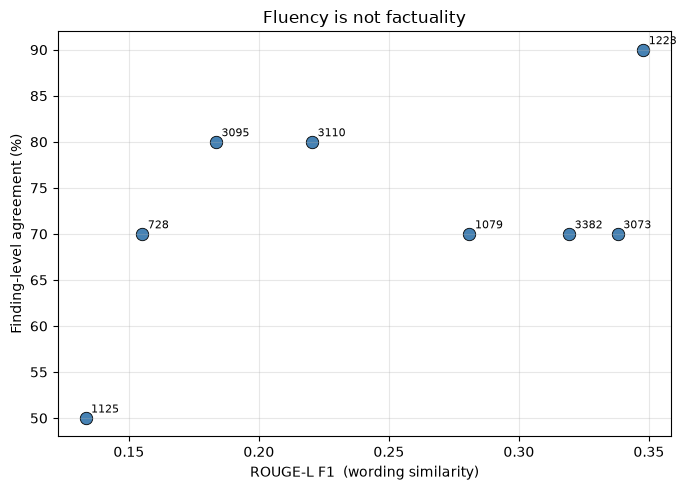

Points in the lower-right scored well on wording but disagreed clinically.
Points in the upper-left were clinically consistent in different words.


In [15]:
# Where do lexical overlap and clinical agreement disagree?
per_case = (agg_df.groupby("uid")["match"].mean().rename("finding_agreement") * 100)
merged = results_df.set_index("uid").join(per_case)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged["rougeL_f1"], merged["finding_agreement"], s=80,
           c="steelblue", edgecolors="black", linewidths=0.6)
for uid, r in merged.iterrows():
    ax.annotate(str(uid), (r["rougeL_f1"], r["finding_agreement"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("ROUGE-L F1  (wording similarity)")
ax.set_ylabel("Finding-level agreement (%)")
ax.set_title("Fluency is not factuality")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Points in the lower-right scored well on wording but disagreed clinically.")
print("Points in the upper-left were clinically consistent in different words.")

LOWEST ROUGE-L  |  uid=1125  |  ROUGE-L=0.133  |  finding agreement=50%


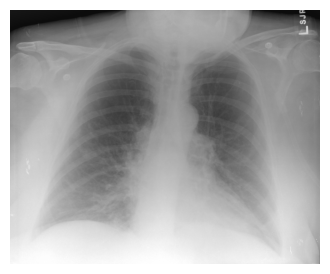

INDICATION: XXXX-year-old with XXXX.

--- GENERATED ---
FINDINGS: LUNGS AND PLEURA: The lungs are clear. No pleural effusion or pneumothorax is identified. HEART AND MEDIASTINUM: The heart size is normal. The mediastinum is unremarkable. BONES AND SOFT TISSUES: The visualized osseous structures are unremarkable. No acute soft tissue abnormality is identified. DEVICES OR LINES: No radiopaque devices or lines are identified.

IMPRESSION:

--- RADIOLOGIST ---
FINDINGS: Borderline enlarged heart. Stable mediastinal contours. Aortic XXXX calcifications. Hyperinflated lungs with chronic appearing interstitial markings, compatible with emphysema. Bilateral streaky opacities. Increased vascularity compatible with pulmonary vascular congestion. No focal airspace disease. No acute bony abnormality.

IMPRESSION: 1. Pulmonary vascular congestion. 2. Emphysema. 3. Bibasilar streaky airspace opacities.

HIGHEST ROUGE-L  |  uid=1223  |  ROUGE-L=0.348  |  finding agreement=90%


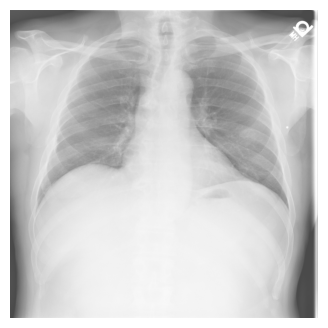

INDICATION: Multiple myeloma

--- GENERATED ---
FINDINGS: LUNGS AND PLEURA: The lungs are clear. No pleural effusion or pneumothorax is identified. HEART AND MEDIASTINUM: The heart size is normal. The mediastinum is normal. The aorta is normal. BONES AND SOFT TISSUES: There is a radiopaque foreign body in the left upper chest wall. The visualized osseous structures are unremarkable.

IMPRESSION: 1. Radiopaque foreign body in the left upper chest wall. 2. No acute pulmonary process.

--- RADIOLOGIST ---
FINDINGS: The heart size and pulmonary vascularity appear within normal limits. Lungs are free of focal airspace disease. No pleural effusion or pneumothorax is seen. XXXX XXXX foreign body is noted in the soft tissues of the left chest wall.

IMPRESSION: No evidence of active disease.



In [16]:
# Read the worst and best case side by side.
worst = merged["rougeL_f1"].idxmin()
best = merged["rougeL_f1"].idxmax()

for tag, uid in [("LOWEST ROUGE-L", worst), ("HIGHEST ROUGE-L", best)]:
    r = merged.loc[uid]
    print("=" * 78)
    print(f"{tag}  |  uid={uid}  |  ROUGE-L={r['rougeL_f1']:.3f}  "
          f"|  finding agreement={r['finding_agreement']:.0f}%")
    print("=" * 78)
    display_img = Image.open(r["image_path"]).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(display_img, cmap="gray")
    plt.axis("off")
    plt.show()
    print("INDICATION:", r["indication"])
    print()
    print("--- GENERATED ---")
    print(r["generated"])
    print()
    print("--- RADIOLOGIST ---")
    print(r["reference"])
    print()

---
## Section 10. Does Clinical Context Help, or Bias?
*When clinical context changes a model's answer, is
it improving interpretation or encouraging an unsupported assumption?*

Here is a direct test. We generate three reports from the **same image**:

1. **No context** — image and schema only
2. **True indication** — the real indication from the report
3. **Misleading indication** — a plausible but wrong clinical question

If the model is reading the image, condition 3 should barely change the findings. If
the model is anchoring on the prompt, condition 3 will produce findings that support
the false indication. Watch what happens.

In [17]:
MISLEADING_INDICATION = "Acute shortness of breath. Rule out large left pleural effusion."

conditions = {
    "no context": None,
    "true indication": demo[R_INDICATION],
    "misleading indication": MISLEADING_INDICATION,
}

ablation = {}
for label, indication in conditions.items():
    print(f"Generating: {label} ...")
    ablation[label] = generate_report(img, indication)

print("\nDone.\n")

for label, text in ablation.items():
    print("=" * 78)
    print(f"CONDITION: {label}")
    print(f"context given: {conditions[label] if conditions[label] else '(none)'}")
    print("=" * 78)
    print(parse_report(text)["FINDINGS"])
    print()

Generating: no context ...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Generating: true indication ...
Generating: misleading indication ...

Done.

CONDITION: no context
context given: (none)
The lungs are clear. There is no pleural effusion or pneumothorax. The cardiomediastinal silhouette is normal. The heart size is normal. The mediastinum is normal. The visualized bones are unremarkable. No devices or lines are seen.

CONDITION: true indication
context given: XXXX-year-old male with XXXX and rib pain.
The lungs are clear. There is no pleural effusion or pneumothorax. The cardiomediastinal silhouette is normal. The heart size is normal. The mediastinum is normal. The visualized bones are unremarkable. No devices or lines are seen.

CONDITION: misleading indication
context given: Acute shortness of breath. Rule out large left pleural effusion.
The lungs are clear. There is no pleural effusion. The cardiomediastinal silhouette is normal. The heart size is normal. The mediastinum is normal. The visualized osseous structures are unremarkable. No pneumotho

In [18]:
# Did the misleading indication pull the report toward its premise?
effusion_terms = FINDING_TERMS["pleural effusion"]

print(f"{'condition':<24} {'pleural effusion':<18} {'ROUGE-L vs radiologist'}")
print("-" * 70)
for label, text in ablation.items():
    body = generated_body(parse_report(text))
    status = assert_status(body, effusion_terms)
    rl = scorer.score(ref_text, body)["rougeL"].fmeasure
    print(f"{label:<24} {status:<18} {rl:.3f}")

print()
print(f"radiologist reference    {assert_status(ref_text, effusion_terms):<18} —")

condition                pleural effusion   ROUGE-L vs radiologist
----------------------------------------------------------------------
no context               absent             0.338
true indication          absent             0.338
misleading indication    absent             0.243

radiologist reference    absent             —
